# Data Analysis and Model Training for the Breast Cancer Wisconsin (Diagnostic)

# Experimental Protocol – Breast Cancer Prediction

## Purpose of this Notebook

This notebook constitutes the experimental backbone for one dataset in a
multi-dataset comparative study on binary medical classification.

The objectives are:
1. To establish strong classical machine learning baselines.
2. To evaluate whether deep learning models provide measurable benefits
   on tabular medical data.
3. To assess model robustness, uncertainty, and statistical significance.
4. To analyze model interpretability using post-hoc explanation techniques.

The results generated here are intended to be directly reusable in a
peer-reviewed scientific publication.

## Experimental Roadmap

1. Dataset characterization and exploratory analysis  
2. Preprocessing and robustness handling  
3. Classical ML benchmarking with cross-validation  
4. Statistical significance testing  
5. Model interpretability analysis  
6. Deep learning comparison  


The *Breast Cancer Wisconsin (Diagnostic)* dataset. It contains detailed information on 569 females. Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. They describe characteristics of the cell nuclei present in the image.The objective of the dataset is to  predict whether the cancer is benign or malignant. Based on these features, multiple machine learning models will be trained, and their predictive performance and metrics will be compared.

First, let us install the basic libraries required for this analysis:

Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import random
import itertools
import time

from scipy.stats.mstats import winsorize
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

import shap

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

### Reproducibility

In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

Next, we load the data into a pandas DataFrame `df` and inspect the first records.

Load Data

In [3]:
path = r'breast_cancer_data.csv'
df = pd.read_csv(path)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 1. Basic Dataset Information

At first glance, all features except the target variable (diagnosis) appear to be numerical. Let us examine the basic dataset metadata.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

The dataset contains 569 rows, where each row represents one individual, and 32 columns, each corresponding to a feature.

There are no missing values, and all features except diagnosis are numerical. The id column is of integer type, the remaining features are of floating-point type.

Below is a description of the columns:

Ten real-valued features are computed for each cell nucleus:

a) radius (mean of distances from center to points on the perimeter)

b) texture (standard deviation of gray-scale values)

c) perimeter

d) area

e) smoothness (local variation in radius lengths)

f) compactness (perimeter^2 / area - 1.0)

g) concavity (severity of concave portions of the contour)

h) concave points (number of concave portions of the contour)

i) symmetry

j) fractal dimension ("coastline approximation" - 1)


The mean, standard error and "worst" or largest (mean of the three
largest values) of these features were computed for each image,
resulting in 30 features. For instance, field 3 is Mean Radius, field
13 is Radius SE, field 23 is Worst Radius.

All feature values are recoded with four significant digits.

The diagnosis column represents the target variable that the models will predict.

### Class Distribution

In [5]:
class_counts = df['diagnosis'].value_counts()
class_ratios = class_counts / len(df)

display(pd.DataFrame({
    "Count": class_counts,
    "Ratio": class_ratios
}))

,Count,Ratio
diagnosis,,
B,357,0.627417
M,212,0.372583


The dataset is moderately imbalanced, with a ratio of about 63% for class B and 37% for class M.
Stratified cross-validation is used to ensure each fold maintains similar class proportions.

## 2. Removal of Redundant Columns and Target Column Mapping

The `id` column is a unique identifier, so we'll drop it. The `Unnamed: 32` column contains all null values, so we'll drop it, too.

In [6]:
df = df.drop(columns=['id', 'Unnamed: 32'])

Also, the diagnosis column contains two possible values: B (for benign) and M (for malignant). These can be easily mapped to integer values:

In [7]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Feature Statistics

We examine descriptive statistics for all features:

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


The reported statistics include:

- count — number of non-missing values
- mean — arithmetic mean
- std — standard deviation
- min — minimum value
- 25% — first quartile
- 50% — median
- 75% — third quartile
- max — maximum value

## 4. Missing Values

We verify the presence of missing values:

In [9]:
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


No missing values are present in the dataset.

## 5. Duplicate Records

We check for duplicate rows:

In [10]:
df.duplicated().value_counts()

,count
False,569


There aren't any duplicates in the dataset.

## 6. Outliers

We first analyze and then handle the outliers.

Two helper functions are defined:

- A function to compute outlier thresholds and summarize extreme values
- A function to visualize distributions using boxplots

In [11]:
def analyze_outliers(column, low=0, high=0, total=0):
    Q1 = df[column].quantile(.25)
    Q3 = df[column].quantile(.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_outliers_low = df[df[column] < lower_limit]
    df_outliers_high = df[df[column] > upper_limit]
    df_outliers_total = pd.concat([df_outliers_low, df_outliers_high])

    low_outliers_count = len(df_outliers_low)
    high_outliers_count = len(df_outliers_high)
    total_outliers_count = len(df_outliers_total)

    summary = f'''
lower quartile: {Q1}
upper quartile: {Q3}
interquartile range: {IQR}
lower limit: {lower_limit}
upper limit: {upper_limit}
number of outliers below the minimum: {low_outliers_count}
number of outliers above the maximum: {high_outliers_count}
total number of outliers: {total_outliers_count}
'''

    print(summary)

    if low > 0:
        print(f'Outliers below the minimum (number of records: {low}):\n')
        print(df_outliers_low.sort_values(by=column).head(low))

    if high > 0:
        print(f'Outliers above the maximum (number of records: {high}):\n')
        print(df_outliers_high.sort_values(by=column).head(high))

    if total > 0:
        print(f'Total outliers (number of records: {total}):\n')
        print(df_outliers_total.sort_values(by=column).head(total))

In [12]:
def show_outliers(column):
    plt.figure(figsize=(10, 1))
    sns.boxplot(data=df, x=df[column], orient="h")
    plt.grid()

The outlier analysis indicates:

**`radius_mean`**

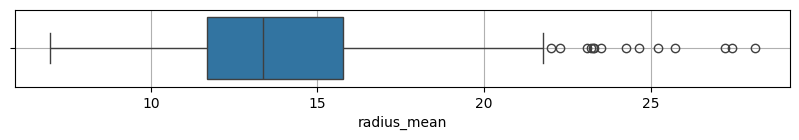

In [13]:
show_outliers('radius_mean')

Several high-end outliers exist:

In [14]:
analyze_outliers('radius_mean', low=5, high=5, total=0)


lower quartile: 11.7
upper quartile: 15.78
interquartile range: 4.08
lower limit: 5.579999999999999
upper limit: 21.9
number of outliers below the minimum: 0
number of outliers above the maximum: 14
total number of outliers: 14

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
369          1        22.01         21.

**`texture_mean`**

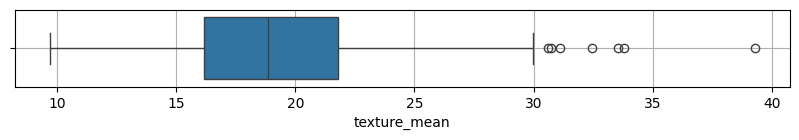

In [15]:
show_outliers('texture_mean')

Several high-end outliers exist:

In [16]:
analyze_outliers('texture_mean', low=5, high=5, total=0)


lower quartile: 16.17
upper quartile: 21.8
interquartile range: 5.629999999999999
lower limit: 7.725000000000003
upper limit: 30.244999999999997
number of outliers below the minimum: 0
number of outliers above the maximum: 7
total number of outliers: 7

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
562          1

**`perimeter_mean`**

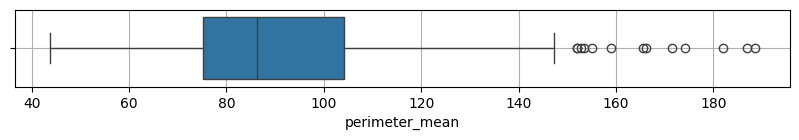

In [17]:
show_outliers('perimeter_mean')

Several high-end outliers exist.

In [18]:
analyze_outliers('perimeter_mean', low=5, high=5, total=0)


lower quartile: 75.17
upper quartile: 104.1
interquartile range: 28.929999999999993
lower limit: 31.775000000000013
upper limit: 147.49499999999998
number of outliers below the minimum: 0
number of outliers above the maximum: 13
total number of outliers: 13

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
164      

**`area_mean`**

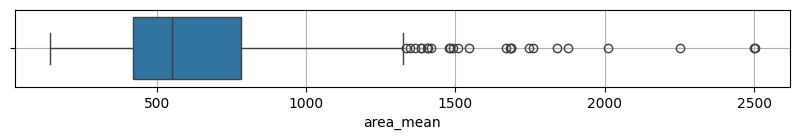

In [19]:
show_outliers('area_mean')

Several high-end outliers exist:

In [20]:
analyze_outliers('area_mean', low=5, high=5, total=0)


lower quartile: 420.3
upper quartile: 782.7
interquartile range: 362.40000000000003
lower limit: -123.30000000000001
upper limit: 1326.3000000000002
number of outliers below the minimum: 0
number of outliers above the maximum: 25
total number of outliers: 25

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
373     

**`smoothness_mean`**

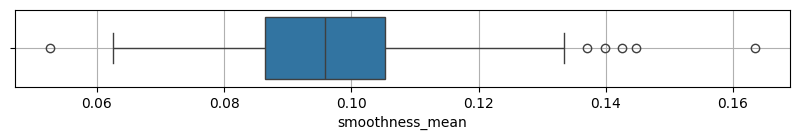

In [21]:
show_outliers('smoothness_mean')

Several outliers on both ends exist:

In [22]:
analyze_outliers('smoothness_mean', low=5, high=5, total=0)


lower quartile: 0.08637
upper quartile: 0.1053
interquartile range: 0.018930000000000002
lower limit: 0.057975
upper limit: 0.133695
number of outliers below the minimum: 1
number of outliers above the maximum: 5
total number of outliers: 6

Outliers below the minimum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
568          0         7.76         24.54           47.92      181.0   

     smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
568          0.05263           0.04362             0.0                  0.0   

     symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
568         0.1587  ...         9.456          30.37            59.16   

     area_worst  smoothness_worst  compactness_worst  concavity_worst  \
568       268.6           0.08996            0.06444              0.0   

     concave points_worst  symmetry_worst  fractal_dimension_worst  
568                   0.0          0.2

**`compactness_mean`**

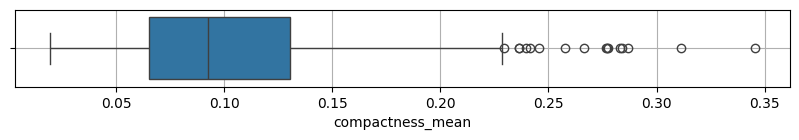

In [23]:
show_outliers('compactness_mean')

Several high-end outliers exist:

In [24]:
analyze_outliers('compactness_mean', low=5, high=5, total=0)


lower quartile: 0.06492
upper quartile: 0.1304
interquartile range: 0.06547999999999998
lower limit: -0.03329999999999997
upper limit: 0.22861999999999996
number of outliers below the minimum: 0
number of outliers above the maximum: 16
total number of outliers: 16

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
14

**`concavity_mean`**

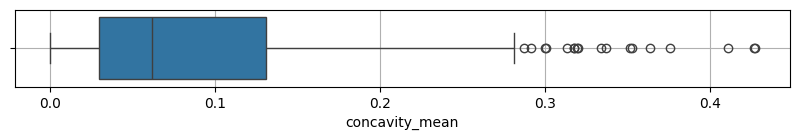

In [25]:
show_outliers('concavity_mean')

Many high-end outliers exist:

In [26]:
analyze_outliers('concavity_mean', low=5, high=5, total=0)


lower quartile: 0.02956
upper quartile: 0.1307
interquartile range: 0.10114000000000001
lower limit: -0.12215000000000001
upper limit: 0.28241000000000005
number of outliers below the minimum: 0
number of outliers above the maximum: 18
total number of outliers: 18

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
18

**`concave points_mean`**

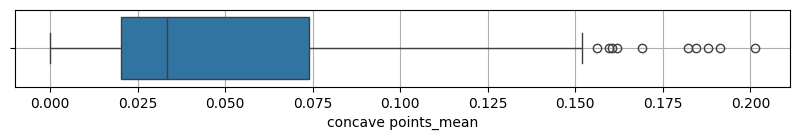

In [27]:
show_outliers('concave points_mean')

Several high-end outliers exist:

In [28]:
analyze_outliers('concave points_mean', low=5, high=5, total=0)


lower quartile: 0.02031
upper quartile: 0.074
interquartile range: 0.053689999999999995
lower limit: -0.060224999999999994
upper limit: 0.15453499999999998
number of outliers below the minimum: 0
number of outliers above the maximum: 10
total number of outliers: 10

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
3

**`symmetry_mean`**

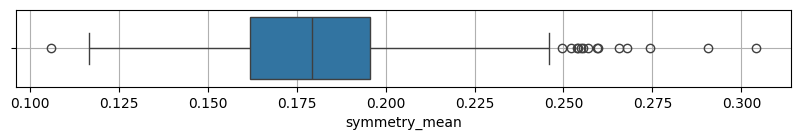

In [29]:
show_outliers('symmetry_mean')

Several high-end outliers exist:

In [30]:
analyze_outliers('symmetry_mean', low=5, high=5, total=0)


lower quartile: 0.1619
upper quartile: 0.1957
interquartile range: 0.033800000000000024
lower limit: 0.11119999999999995
upper limit: 0.24640000000000006
number of outliers below the minimum: 1
number of outliers above the maximum: 14
total number of outliers: 15

Outliers below the minimum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
561          0         11.2         29.37           70.67      386.0   

     smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
561          0.07449           0.03558             0.0                  0.0   

     symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
561          0.106  ...         11.92           38.3            75.19   

     area_worst  smoothness_worst  compactness_worst  concavity_worst  \
561       439.6           0.09267            0.05494              0.0   

     concave points_worst  symmetry_worst  fractal_dimension_worst  
561            

**`fractal_dimension_mean`**

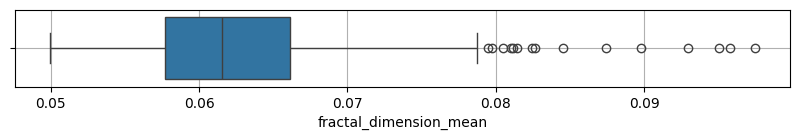

In [31]:
show_outliers('fractal_dimension_mean')

Several high-end outliers exist:

In [32]:
analyze_outliers('fractal_dimension_mean', low=5, high=5, total=0)


lower quartile: 0.0577
upper quartile: 0.06612
interquartile range: 0.008419999999999997
lower limit: 0.045070000000000006
upper limit: 0.07874999999999999
number of outliers below the minimum: 0
number of outliers above the maximum: 15
total number of outliers: 15

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
3

**`radius_se`**

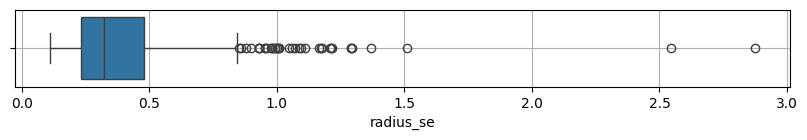

In [33]:
show_outliers('radius_se')

Many high-end outliers exist:

In [34]:
analyze_outliers('radius_se', low=5, high=5, total=0)


lower quartile: 0.2324
upper quartile: 0.4789
interquartile range: 0.2465
lower limit: -0.13735000000000003
upper limit: 0.84865
number of outliers below the minimum: 0
number of outliers above the maximum: 38
total number of outliers: 38

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
27           1        18.61 

**`texture_se`**

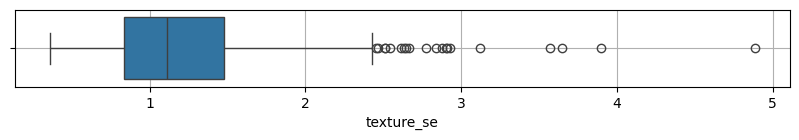

In [35]:
show_outliers('texture_se')

Several high-end outliers exist:

In [36]:
analyze_outliers('texture_se', low=5, high=5, total=0)


lower quartile: 0.8339
upper quartile: 1.474
interquartile range: 0.6401
lower limit: -0.12625000000000008
upper limit: 2.43415
number of outliers below the minimum: 0
number of outliers above the maximum: 20
total number of outliers: 20

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
258          1        15.66  

**`perimeter_se`**

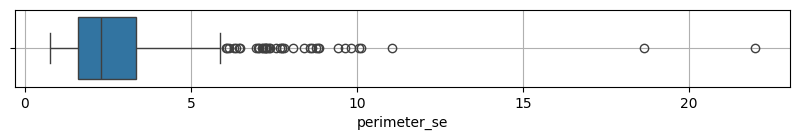

In [37]:
show_outliers('perimeter_se')

Many high-end outliers exist:

In [38]:
analyze_outliers('perimeter_se', low=5, high=5, total=0)


lower quartile: 1.606
upper quartile: 3.357
interquartile range: 1.7510000000000001
lower limit: -1.0205
upper limit: 5.9835
number of outliers below the minimum: 0
number of outliers above the maximum: 38
total number of outliers: 38

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
460          1        17.08     

**`area_se`**

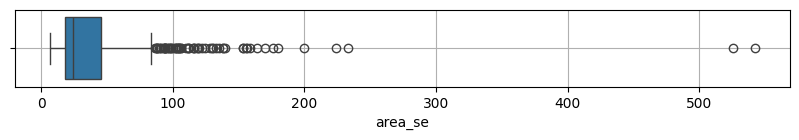

In [39]:
show_outliers('area_se')

Many high-end outliers exist:

In [40]:
analyze_outliers('area_se', low=5, high=5, total=0)


lower quartile: 17.85
upper quartile: 45.19
interquartile range: 27.339999999999996
lower limit: -23.15999999999999
upper limit: 86.19999999999999
number of outliers below the minimum: 0
number of outliers above the maximum: 65
total number of outliers: 65

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
567       

**`smoothness_se`**

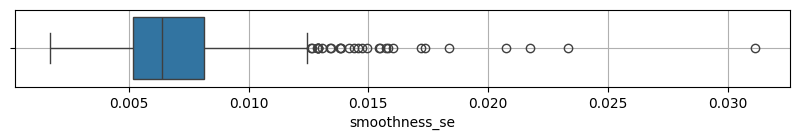

In [41]:
show_outliers('smoothness_se')

Several high-end outliers exist:

In [42]:
analyze_outliers('smoothness_se', low=5, high=5, total=0)


lower quartile: 0.005169
upper quartile: 0.008146
interquartile range: 0.0029770000000000005
lower limit: 0.0007034999999999993
upper limit: 0.012611500000000001
number of outliers below the minimum: 0
number of outliers above the maximum: 30
total number of outliers: 30

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mea

**`compactness_se`**

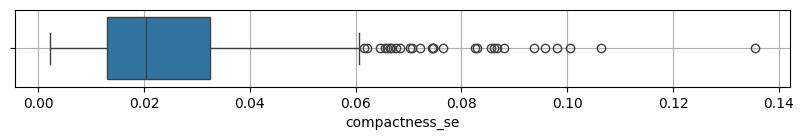

In [43]:
show_outliers('compactness_se')

Several high-end outliers exist:

In [44]:
analyze_outliers('compactness_se', low=5, high=5, total=0)


lower quartile: 0.01308
upper quartile: 0.03245
interquartile range: 0.01937
lower limit: -0.015974999999999996
upper limit: 0.061505
number of outliers below the minimum: 0
number of outliers above the maximum: 28
total number of outliers: 28

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
567          1       20

**`concavity_se`**

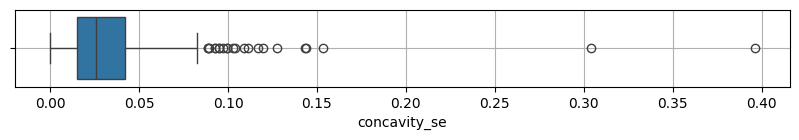

In [45]:
show_outliers('concavity_se')

Several high-end outliers exist:

In [46]:
analyze_outliers('concavity_se', low=5, high=5, total=0)


lower quartile: 0.01509
upper quartile: 0.04205
interquartile range: 0.026959999999999998
lower limit: -0.025349999999999998
upper limit: 0.08249
number of outliers below the minimum: 0
number of outliers above the maximum: 22
total number of outliers: 22

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
242        

**`concave points_se`**

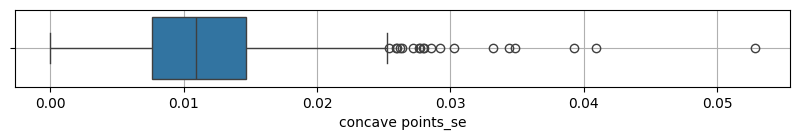

In [47]:
show_outliers('concave points_se')

Several high-end outliers exist:

In [48]:
analyze_outliers('concave points_se', low=5, high=5, total=0)


lower quartile: 0.007638
upper quartile: 0.01471
interquartile range: 0.007072000000000001
lower limit: -0.0029700000000000013
upper limit: 0.025318
number of outliers below the minimum: 0
number of outliers above the maximum: 19
total number of outliers: 19

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
366     

**`symmetry_se`**

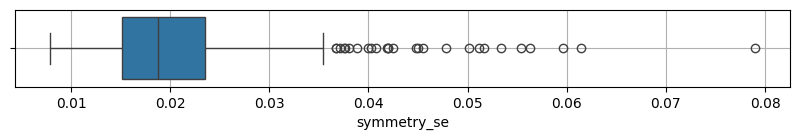

In [49]:
show_outliers('symmetry_se')

Several high-end outliers exist:

In [50]:
analyze_outliers('symmetry_se', low=5, high=5, total=0)


lower quartile: 0.01516
upper quartile: 0.02348
interquartile range: 0.008320000000000001
lower limit: 0.0026799999999999984
upper limit: 0.035960000000000006
number of outliers below the minimum: 0
number of outliers above the maximum: 27
total number of outliers: 27

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  

**`fractal_dimension_se`**

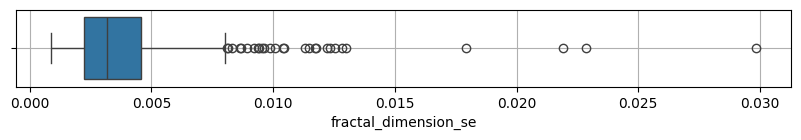

In [51]:
show_outliers('fractal_dimension_se')

Several high-end outliers exist:

In [52]:
analyze_outliers('fractal_dimension_se', low=5, high=5, total=0)


lower quartile: 0.002248
upper quartile: 0.004558
interquartile range: 0.0023100000000000004
lower limit: -0.0012170000000000006
upper limit: 0.008023
number of outliers below the minimum: 0
number of outliers above the maximum: 28
total number of outliers: 28

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
14    

**`radius_worst`**

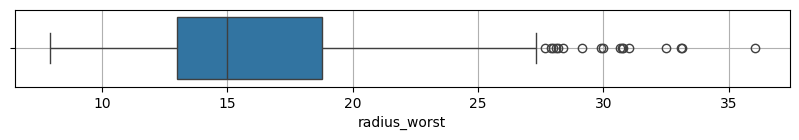

In [53]:
show_outliers('radius_worst')

Several high-end outliers exist:

In [54]:
analyze_outliers('radius_worst', low=5, high=5, total=0)


lower quartile: 13.01
upper quartile: 18.79
interquartile range: 5.779999999999999
lower limit: 4.340000000000002
upper limit: 27.459999999999997
number of outliers below the minimum: 0
number of outliers above the maximum: 17
total number of outliers: 17

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
369        

**`texture_worst`**

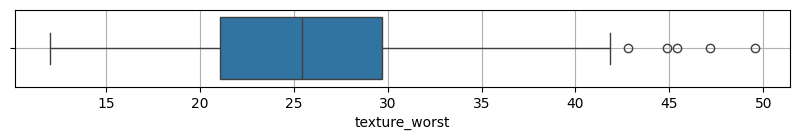

In [55]:
show_outliers('texture_worst')

Several high-end outliers exist:

In [56]:
analyze_outliers('texture_worst', low=5, high=5, total=0)


lower quartile: 21.08
upper quartile: 29.72
interquartile range: 8.64
lower limit: 8.119999999999997
upper limit: 42.68
number of outliers below the minimum: 0
number of outliers above the maximum: 5
total number of outliers: 5

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
562          1        15.22         30.

**`perimeter_worst`**

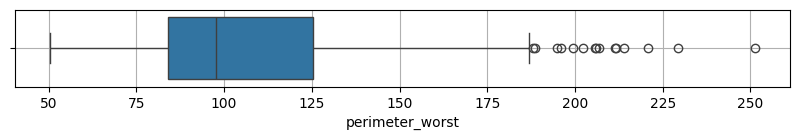

In [57]:
show_outliers('perimeter_worst')

Several high-end outliers exist:

In [58]:
analyze_outliers('perimeter_worst', low=5, high=5, total=0)


lower quartile: 84.11
upper quartile: 125.4
interquartile range: 41.290000000000006
lower limit: 22.17499999999999
upper limit: 187.335
number of outliers below the minimum: 0
number of outliers above the maximum: 15
total number of outliers: 15

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
23           1       

**`area_worst`**

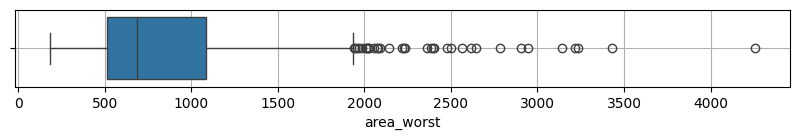

In [59]:
show_outliers('area_worst')

Several high-end outliers exist:

In [60]:
analyze_outliers('area_worst', low=5, high=5, total=0)


lower quartile: 515.3
upper quartile: 1084.0
interquartile range: 568.7
lower limit: -337.7500000000001
upper limit: 1937.0500000000002
number of outliers below the minimum: 0
number of outliers above the maximum: 35
total number of outliers: 35

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
323          1       

**`smoothness_worst`**

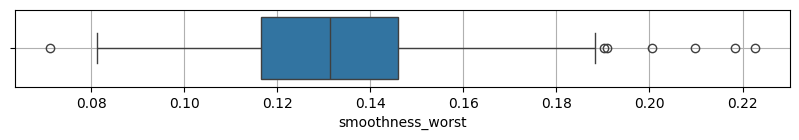

In [61]:
show_outliers('smoothness_worst')

Several outliers on both ends exist:

In [62]:
analyze_outliers('smoothness_worst', low=5, high=5, total=0)


lower quartile: 0.1166
upper quartile: 0.146
interquartile range: 0.029399999999999996
lower limit: 0.07250000000000001
upper limit: 0.1901
number of outliers below the minimum: 1
number of outliers above the maximum: 6
total number of outliers: 7

Outliers below the minimum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
192          0         9.72         18.22           60.73      288.1   

     smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
192           0.0695           0.02344             0.0                  0.0   

     symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
192         0.1653  ...         9.968          20.83            62.25   

     area_worst  smoothness_worst  compactness_worst  concavity_worst  \
192       303.8           0.07117            0.02729              0.0   

     concave points_worst  symmetry_worst  fractal_dimension_worst  
192                   0.0      

**`compactness_worst`**

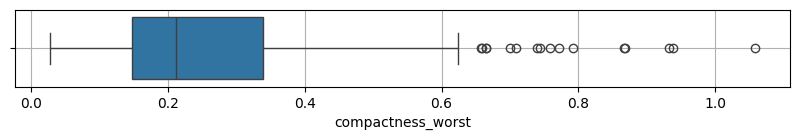

In [63]:
show_outliers('compactness_worst')

Several high-end outliers exist:

In [64]:
analyze_outliers('compactness_worst', low=5, high=5, total=0)


lower quartile: 0.1472
upper quartile: 0.3391
interquartile range: 0.19190000000000002
lower limit: -0.14065000000000005
upper limit: 0.6269500000000001
number of outliers below the minimum: 0
number of outliers above the maximum: 16
total number of outliers: 16

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
15  

**`concavity_worst`**

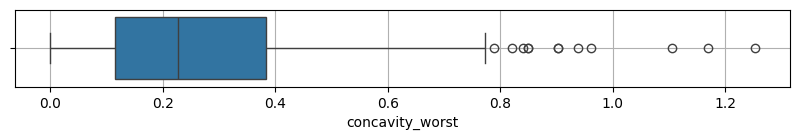

In [65]:
show_outliers('concavity_worst')

Several high-end outliers exist:

In [66]:
analyze_outliers('concavity_worst', low=5, high=5, total=0)


lower quartile: 0.1145
upper quartile: 0.3829
interquartile range: 0.2684
lower limit: -0.2881000000000001
upper limit: 0.7855000000000001
number of outliers below the minimum: 0
number of outliers above the maximum: 12
total number of outliers: 12

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
202          1    

**`concave points_worst`**

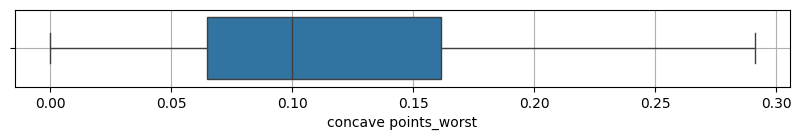

In [67]:
show_outliers('concave points_worst')

No outliers exist.

**`symmetry_worst`**

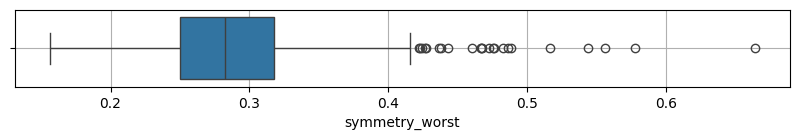

In [68]:
show_outliers('symmetry_worst')

Several high-end outliers exist:

In [69]:
analyze_outliers('symmetry_worst', low=5, high=5, total=0)


lower quartile: 0.2504
upper quartile: 0.3179
interquartile range: 0.0675
lower limit: 0.14915
upper limit: 0.41915
number of outliers below the minimum: 0
number of outliers above the maximum: 23
total number of outliers: 23

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
15           1       14.540         27.54

**`fractal_dimension_worst`**

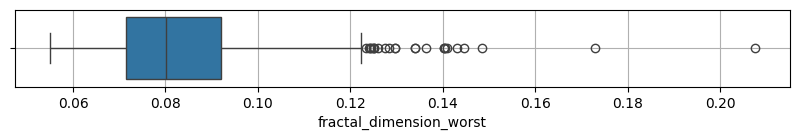

In [70]:
show_outliers('fractal_dimension_worst')

Several high-end outliers exist:

In [71]:
analyze_outliers('fractal_dimension_worst', low=5, high=5, total=0)


lower quartile: 0.07146
upper quartile: 0.09208
interquartile range: 0.02062
lower limit: 0.04053
upper limit: 0.12301
number of outliers below the minimum: 0
number of outliers above the maximum: 24
total number of outliers: 24

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 31 columns]
Outliers above the maximum (number of records: 5):

     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
34           1        16.13         17

### Winsorization

All data is retained as far as outliers are concerned, but we reduce the influence of extreme values by means of winsorization:

In [72]:
WIN_LIMITS = (0.01, 0.01)

def winsorize_column(col, limits=WIN_LIMITS):
    # Applies winsorization to a pandas Series (column).
    # limits: A tuple (lower_limit, upper_limit) defining the percentiles for winsorization.
    return winsorize(col, limits=limits)

# Apply winsorization to all columns except the target column to reduce the impact of extreme outliers
feature_cols = [col for col in df.columns if col != 'diagnosis']
for col in feature_cols:
    df[col] = winsorize_column(df[col])

Winsorization identifies values below a certain lower percentile and above a certain upper percentile. It then replaces all values below the lower percentile with the value at that lower percentile, and all values above the upper percentile with the value at that upper percentile.

It's convenient because it retains all data points, preventing data loss that would occur if extreme outliers were simply removed. It reduces the undue influence of highly anomalous values (like the physiologically implausible blood pressure or height/weight readings observed during outlier analysis) on statistical analyses and machine learning models, without discarding potentially valuable information.

## 7. Data Cleaning and Preprocessing

### Feature / target split

In [73]:
# Separate features (X) from the target variable (y)
X = df.drop(columns="diagnosis") # Features DataFrame
y = df["diagnosis"] # Target Series (diabetes presence)

## 8. Pipelines and Hyperparameters

In [74]:
# Define a dictionary to store machine learning pipelines and their corresponding hyperparameter grids.
# Each entry consists of a pipeline object and a dictionary of hyperparameters for RandomizedSearchCV.
pipelines = {
    "Logistic Regression": (
        # Pipeline for Logistic Regression: first scales data, then applies Logistic Regression.
        Pipeline([
            ("scaler", StandardScaler()), # Standardize features by removing the mean and scaling to unit variance
            ("model", LogisticRegression(
                max_iter=2000, # Maximum number of iterations for the solver to converge
                class_weight="balanced", # Adjust weights inversely proportional to class frequencies
                random_state=SEED # Seed for reproducibility
            ))
        ]),
        # Hyperparameter grid for Logistic Regression: tuning the regularization strength (C)
        {"model__C": np.logspace(-3, 3, 20)} # C is the inverse of regularization strength
    ),

    "KNN": (
        # Pipeline for K-Nearest Neighbors: scales data, then applies KNN.
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier()) # K-Nearest Neighbors classifier
        ]),
        # Hyperparameter grid for KNN: tuning number of neighbors and weight function
        {
            "model__n_neighbors": [3, 5, 7, 9, 11], # Number of neighbors to use
            "model__weights": ["uniform", "distance"] # Weight function used in prediction
        }
    ),

    "Decision Tree": (
        # Pipeline for Decision Tree: no scaling needed as tree-based models are not sensitive to scale.
        Pipeline([
            ("model", DecisionTreeClassifier(
                class_weight="balanced",
                random_state=SEED
            ))
        ]),
        # Hyperparameter grid for Decision Tree: tuning tree depth and minimum samples for a split
        {
            "model__max_depth": [None, 5, 10, 20], # Maximum depth of the tree
            "model__min_samples_split": [2, 5, 10] # Minimum number of samples required to split an internal node
        }
    ),

    "Random Forest": (
        # Pipeline for Random Forest: no scaling needed.
        Pipeline([
            ("model", RandomForestClassifier(
                class_weight="balanced",
                random_state=SEED,
                n_jobs=-1 # Use all available CPU cores
            ))
        ]),
        # Hyperparameter grid for Random Forest: tuning number of estimators and tree depth
        {
            "model__n_estimators": [200, 400], # Number of trees in the forest
            "model__max_depth": [None, 10, 20] # Maximum depth of individual trees
        }
    ),

    "Gradient Boosting": (
        # Pipeline for Gradient Boosting: no scaling needed.
        Pipeline([
            ("model", GradientBoostingClassifier(
                random_state=42)
            ) # Gradient Boosting classifier
        ]),
        # Hyperparameter grid for Gradient Boosting: tuning number of estimators, learning rate, and tree depth
        {
            "model__n_estimators": [100, 200, 400], # Number of boosting stages
            "model__learning_rate": [0.01, 0.05, 0.1], # Step size shrinkage to prevent overfitting
            "model__max_depth": [2, 3, 4] # Maximum depth of the individual regression estimators
        }
    ),

    "Naive Bayes": (
        # Pipeline for Gaussian Naive Bayes: only the model, as it doesn't have complex hyperparameters.
        Pipeline([("model", GaussianNB())]),
        {} # No hyperparameters to tune for Gaussian Naive Bayes in this setup
    )
}

## 9. Nested CV Evaluation

In [75]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED) # 5-fold stratified outer cross-validation

results = {name: [] for name in pipelines} # Dictionary to store performance metrics for each model per fold
probabilities = {name: [] for name in pipelines} # Dictionary to store predicted probabilities for each model across all folds
true_labels = [] # List to store true labels across all folds

print("Starting Classical ML Nested CV Evaluation...")
# Iterate through each fold of the outer cross-validation
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
    print(f"Fold {fold}")

    # Split data into training and test sets for the current fold
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    true_labels.extend(y_test.values) # Collect true labels for later statistical testing

    # Iterate through each defined machine learning pipeline
    for name, (pipe, params) in pipelines.items():
        start_time = time.time() # Start time measurement
        # If hyperparameters are defined, perform Randomized Search Cross-Validation (inner loop)
        if params:
            search = RandomizedSearchCV(
                pipe, # The pipeline to optimize
                params, # The hyperparameter distribution to sample from
                n_iter=20, # Number of parameter settings that are sampled
                scoring="roc_auc", # Metric to optimize for (keeping original)
                cv=3, # 3-fold cross-validation for the inner loop
                n_jobs=-1, # Use all available CPU cores
                random_state=SEED # Seed for reproducibility
            )
            search.fit(X_train, y_train) # Fit the randomized search on the training data
            model = search.best_estimator_ # Select the best model found by RandomizedSearchCV
        else:
            # If no hyperparameters, fit the pipeline directly
            model = pipe.fit(X_train, y_train)

        end_time = time.time() # End time measurement
        train_time = end_time - start_time # Calculate training time

        # Predict probabilities on the test set
        y_prob = model.predict_proba(X_test)[:, 1] # Probability of the positive class
        y_pred = (y_prob >= 0.5).astype(int) # Convert probabilities to binary predictions (threshold 0.5)

        # Store evaluation metrics and training time for the current fold
        metrics_dict = {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "ROC_AUC": roc_auc_score(y_test, y_prob),
            "Average Precision": average_precision_score(y_test, y_prob),
            "Train Time": train_time
        }
        results[name].append(metrics_dict)

        # Store predicted probabilities for later statistical testing (Wilcoxon test)
        probabilities[name].extend(y_prob)
print("Classical ML Nested CV Evaluation Complete.")

Starting Classical ML Nested CV Evaluation...
Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Classical ML Nested CV Evaluation Complete.


## 10. Aggregated Results

In [76]:
summary = {} # Dictionary to hold mean results for each model

# Calculate the mean of performance metrics across all folds for each model
for name, fold_results in results.items():
    df_tmp = pd.DataFrame(fold_results) # Convert fold results to a DataFrame
    summary[name] = df_tmp.mean() # Calculate mean for each metric

results_df = pd.DataFrame(summary).T # Convert the summary dictionary to a DataFrame, transpose for better readability
results_df

,Accuracy,Precision,Recall,F1,ROC_AUC,Average Precision,Train Time
Logistic Regression,0.975423,0.968455,0.967110,0.967201,0.995576,0.994655,1.451976
KNN,0.963096,0.980306,0.919823,0.948545,0.989395,0.986756,0.410839
Decision Tree,0.922652,0.897767,0.900997,0.897746,0.933898,0.883354,0.516130
Random Forest,0.964850,0.959835,0.948062,0.952414,0.990237,0.988423,12.847428
Gradient Boosting,0.954324,0.961650,0.915393,0.936691,0.991874,0.989651,58.793130
Naive Bayes,0.933256,0.933450,0.891473,0.908733,0.986866,0.973364,0.003825


## 11. SHAP (trained on full data)

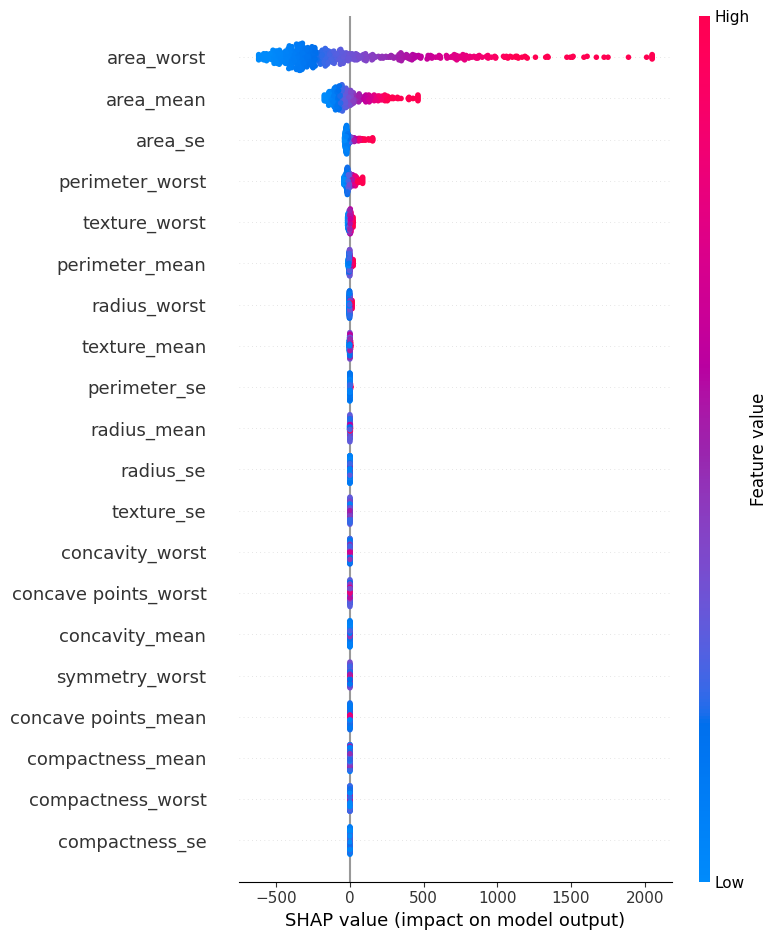

In [77]:
best_pipe, best_params = pipelines["Logistic Regression"] # Retrieve the pipeline and parameters for Logistic Regression

# Train the best model on the entire dataset (X, y) for SHAP analysis.
# .named_steps["model"] extracts the actual model object from the pipeline.
best_model = best_pipe.fit(X, y).named_steps["model"]

# Initialize a LinearExplainer for linear models like Logistic Regression
explainer = shap.LinearExplainer(best_model, X)
# Calculate SHAP values for the entire feature set X
shap_values = explainer.shap_values(X)

# Generate a summary plot of SHAP values. This plot shows feature importance
# and the impact of each feature on the model's output.
shap.summary_plot(shap_values, X)

The Breast Cancer dataset has 30 highly correlated features (these are the same measurements in different forms: mean, SE, worst). This may favor models that are robust to multicollinearity (such as regularized logistic regression or tree-based models).

This SHAP summary plot visualizes the impact of each feature on the model's predictions. Here's how to interpret it:

*   **Feature Importance**: Features are ordered vertically by their importance, with the most impactful features at the top.
*   **Impact on Output**: The horizontal axis represents the SHAP value, indicating the change in the model's output prediction. Positive SHAP values push the prediction higher, and negative values push it lower.
*   **Feature Value (Color)**: The color of each dot represents the actual value of that feature for a given observation. Red indicates a high feature value, and blue indicates a low feature value.
*   **Density of Points**: The plot shows a point for each observation in the dataset. Overlapping points create a density, giving a sense of the distribution of SHAP values for that feature.

From this plot, you can see how high or low values of a feature tend to influence the prediction towards a malignant (positive SHAP values) or benign (negative SHAP values) diagnosis. For example, if a feature like 'area_worst' shows many red dots extending to positive SHAP values, it means high values of 'area_worst' strongly contribute to a prediction of malignancy.

## 12. Deep Learning Model: Multilayer Perceptron (PyTorch)

In addition to traditional machine learning models, a deep learning approach was implemented using PyTorch. The objective was to evaluate whether a neural network can outperform classical classifiers on the cardiovascular disease prediction task.

A **Multilayer Perceptron (MLP)** architecture was selected due to its suitability for tabular biomedical data.

In [78]:
def set_seed(seed=42):
    # Set seed for reproducibility across numpy and torch
    np.random.seed(seed)
    torch.manual_seed(seed)
    # Set CUDA seed for GPU operations if available
    torch.cuda.manual_seed_all(seed)
    # Ensure deterministic behavior for CUDA (can impact performance)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [79]:
class MLP(nn.Module):
    # Defines a Multilayer Perceptron (MLP) for binary classification.
    # It includes fully connected layers, ReLU activation, and Dropout regularization.
    def __init__(self, input_dim, hidden_dims=(64, 32), dropout=0.3):
        super().__init__()

        layers = []
        prev_dim = input_dim

        # Dynamically build hidden layers based on `hidden_dims`
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h)) # Fully connected layer
            layers.append(nn.ReLU()) # ReLU activation function
            layers.append(nn.Dropout(dropout)) # Dropout for regularization
            prev_dim = h

        # Output layer: maps to a single output for binary classification
        layers.append(nn.Linear(prev_dim, 1))

        # Combine all layers into a sequential network
        self.network = nn.Sequential(*layers)

    # Defines the forward pass of the network
    def forward(self, x):
        # Pass input through the network and squeeze the output to remove single-dimensional entries
        return self.network(x).squeeze(1)

In [80]:
EPOCHS = 100
LR = 1e-3
PATIENCE = 10

def train_mlp(
    model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR,
    patience=PATIENCE
):
    # Define the loss function (Binary Cross-Entropy with Logits for numerical stability)
    criterion = nn.BCEWithLogitsLoss()
    # Define the optimizer (Adam is a popular choice for deep learning)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_auc = -np.inf # Initialize best validation AUC score
    patience_counter = 0 # Counter for early stopping patience

    start_train_time = time.time() # Start time measurement for training

    # Training loop
    for epoch in range(epochs):
        model.train() # Set model to training mode
        for xb, yb in train_loader:
            optimizer.zero_grad() # Zero the gradients before backpropagation
            logits = model(xb) # Forward pass
            loss = criterion(logits, yb) # Compute loss
            loss.backward() # Backpropagate gradients
            optimizer.step() # Update model parameters

        # Validation phase
        model.eval() # Set model to evaluation mode
        y_true, y_prob = [], []

        with torch.no_grad(): # Disable gradient calculation during validation
            for xb, yb in val_loader:
                logits = model(xb)
                probs = torch.sigmoid(logits) # Convert logits to probabilities
                y_true.extend(yb.cpu().numpy())
                y_prob.extend(probs.cpu().numpy())

        val_auc = roc_auc_score(y_true, y_prob) # Compute ROC AUC on validation set

        # Early stopping logic
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = model.state_dict() # Save the best model state
            patience_counter = 0 # Reset patience counter
        else:
            patience_counter += 1 # Increment patience counter

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break # Stop training if patience runs out

    end_train_time = time.time() # End time measurement for training
    total_train_time = end_train_time - start_train_time

    model.load_state_dict(best_state) # Load the best model state found during training
    return model, total_train_time


In [81]:
param_grid_mlp = {
    'hidden_dims': [(64, 32), (128, 64), (128, 64, 32)],
    'dropout': [0.2, 0.3, 0.4],
    'lr': [1e-4, 1e-3, 1e-2],
    'batch_size': [32, 64, 128]
}

MLP_RANDOM_SEARCH_ITERATIONS = 20 # Number of random hyperparameter combinations to try

mlp_results = [] # List to store evaluation metrics for each fold
mlp_probabilities = [] # List to store predicted probabilities for all folds

# Initialize StratifiedKFold for consistent cross-validation splits
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("Starting MLP Nested CV Evaluation...")
# Iterate through each fold of the outer cross-validation
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
    print(f"MLP – Fold {fold}")

    # Split data into training and test sets for the current fold
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Data Scaling: Apply StandardScaler to training and test data
    # Scaler is fitted only on the training data to prevent data leakage
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Inner validation split: Create a validation set from the training data
    val_split = int(0.8 * len(X_train_scaled))

    X_tr, X_val = X_train_scaled[:val_split], X_train_scaled[val_split:]
    y_tr, y_val = y_train.values[:val_split], y_train.values[val_split:]

    # Convert numpy arrays to PyTorch tensors for model input
    # Datasets for inner loop, batch_size will be set dynamically
    train_ds_inner = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.float32)
    )

    val_ds_inner = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32)
    )

    # Initialize best validation AUC and corresponding hyperparameters for this fold
    best_val_auc_mlp_fold = -np.inf
    best_params_mlp_fold = {}

    # Perform random search for hyperparameters
    for i in range(MLP_RANDOM_SEARCH_ITERATIONS):
        set_seed(SEED + i) # Reset seed for reproducibility of random choices within each iteration

        # Sample hyperparameters
        current_hidden_dims = random.choice(param_grid_mlp['hidden_dims'])
        current_dropout = random.choice(param_grid_mlp['dropout'])
        current_lr = random.choice(param_grid_mlp['lr'])
        current_batch_size = random.choice(param_grid_mlp['batch_size'])

        # Create DataLoaders with sampled batch_size
        train_loader_inner = DataLoader(train_ds_inner, batch_size=current_batch_size, shuffle=True)
        val_loader_inner = DataLoader(val_ds_inner, batch_size=256) # Keep val batch size consistent for evaluation

        # Instantiate MLP model with sampled hyperparameters
        current_model = MLP(input_dim=X.shape[1], hidden_dims=current_hidden_dims, dropout=current_dropout)

        # Train the model
        trained_model, _ = train_mlp(current_model, train_loader_inner, val_loader_inner, lr=current_lr)

        # Evaluate on validation set
        trained_model.eval() # Set model to evaluation mode
        y_true_val, y_prob_val = [], []
        with torch.no_grad():
            for xb_val, yb_val in val_loader_inner:
                logits_val = trained_model(xb_val)
                probs_val = torch.sigmoid(logits_val)
                y_true_val.extend(yb_val.cpu().numpy())
                y_prob_val.extend(probs_val.cpu().numpy())
        current_val_auc = roc_auc_score(y_true_val, y_prob_val)

        # Update best hyperparameters if current model is better
        if current_val_auc > best_val_auc_mlp_fold:
            best_val_auc_mlp_fold = current_val_auc
            best_params_mlp_fold = {
                'hidden_dims': current_hidden_dims,
                'dropout': current_dropout,
                'lr': current_lr,
                'batch_size': current_batch_size
            }
            # print(f"  New best: AUC={current_val_auc:.4f}, Params={best_params_mlp_fold}")

    print(f"  Best params for Fold {fold}: {best_params_mlp_fold}")

    # Train final MLP model for this fold using the best hyperparameters found
    final_mlp_model = MLP(
        input_dim=X.shape[1],
        hidden_dims=best_params_mlp_fold['hidden_dims'],
        dropout=best_params_mlp_fold['dropout']
    )

    # Prepare DataLoaders for final training with best batch_size
    train_loader_final = DataLoader(train_ds_inner, batch_size=best_params_mlp_fold['batch_size'], shuffle=True)
    val_loader_final = DataLoader(val_ds_inner, batch_size=256) # Val loader can use larger batch size

    # Retrain the final model with best hyperparameters
    final_trained_model, mlp_train_time = train_mlp(final_mlp_model, train_loader_final, val_loader_final, lr=best_params_mlp_fold['lr'])

    # Test DataLoaders using the true test set and its labels
    test_ds = TensorDataset(
        torch.tensor(X_test_scaled, dtype=torch.float32),
        torch.tensor(y_test.values, dtype=torch.float32)
    )
    test_loader = DataLoader(test_ds, batch_size=256)

    # Evaluation phase: Make predictions on the test set
    final_trained_model.eval() # Set model to evaluation mode
    y_prob = []
    with torch.no_grad(): # Disable gradient calculation
        for xb, _ in test_loader:
            probs = torch.sigmoid(final_trained_model(xb)) # Get probabilities from logits
            y_prob.extend(probs.cpu().numpy())

    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int) # Convert probabilities to binary predictions

    # Store evaluation metrics for the current fold
    mlp_results.append({
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "Average Precision": average_precision_score(y_test, y_prob),
        "Train Time": mlp_train_time # Add training time here
    })

    # Store predicted probabilities for the Wilcoxon test
    mlp_probabilities.extend(y_prob)
print("MLP Nested CV Evaluation Complete.")


Starting MLP Nested CV Evaluation...
MLP – Fold 1
Early stopping at epoch 80
Early stopping at epoch 32
Early stopping at epoch 13
Early stopping at epoch 12
Early stopping at epoch 62
Early stopping at epoch 13
Early stopping at epoch 13
Early stopping at epoch 25
Early stopping at epoch 23
Early stopping at epoch 22
Early stopping at epoch 62
Early stopping at epoch 25
Early stopping at epoch 13
Early stopping at epoch 44
Early stopping at epoch 78
Early stopping at epoch 12
Early stopping at epoch 30
Early stopping at epoch 37
Early stopping at epoch 29
Early stopping at epoch 12
  Best params for Fold 1: {'hidden_dims': (128, 64), 'dropout': 0.4, 'lr': 0.001, 'batch_size': 32}
Early stopping at epoch 18
MLP – Fold 2
Early stopping at epoch 20
Early stopping at epoch 13
Early stopping at epoch 14
Early stopping at epoch 21
Early stopping at epoch 30
Early stopping at epoch 11
Early stopping at epoch 41
Early stopping at epoch 26
Early stopping at epoch 14
Early stopping at epoch 20


In [82]:
# Original code to collect all fold results into df_results
all_results_list = []

# Iterate through classical model results
for model_name, fold_results in results.items():
    for fold_num, metrics in enumerate(fold_results, 1):
        fold_entry = {
            "model_name": model_name,
            "fold": fold_num
        }
        fold_entry.update(metrics)
        all_results_list.append(fold_entry)

# Iterate through MLP (PyTorch) results
for fold_num, metrics in enumerate(mlp_results, 1):
    fold_entry = {
        "model_name": "MLP (PyTorch)",
        "fold": fold_num
    }
    fold_entry.update(metrics)
    all_results_list.append(fold_entry)

df_results = pd.DataFrame(all_results_list)

print(df_results)


             model_name  fold  Accuracy  Precision    Recall        F1  \
0   Logistic Regression     1  0.964912   0.933333  0.976744  0.954545   
1   Logistic Regression     2  0.964912   0.975610  0.930233  0.952381   
2   Logistic Regression     3  0.982456   1.000000  0.952381  0.975610   
3   Logistic Regression     4  0.973684   0.933333  1.000000  0.965517   
4   Logistic Regression     5  0.991150   1.000000  0.976190  0.987952   
5                   KNN     1  0.982456   1.000000  0.953488  0.976190   
6                   KNN     2  0.947368   0.974359  0.883721  0.926829   
7                   KNN     3  0.947368   0.973684  0.880952  0.925000   
8                   KNN     4  0.973684   0.953488  0.976190  0.964706   
9                   KNN     5  0.964602   1.000000  0.904762  0.950000   
10        Decision Tree     1  0.877193   0.795918  0.906977  0.847826   
11        Decision Tree     2  0.947368   0.974359  0.883721  0.926829   
12        Decision Tree     3  0.93859

In [83]:
dataset_name = "breast_cancer"
df_results.to_csv(f'df_results_{dataset_name}.csv', index=False)
print(f"df_results saved to df_results_{dataset_name}.csv")

full_results_df = pd.DataFrame({
    'Model': df_results.groupby('model_name').mean().index,
    'ROC_AUC': df_results.groupby('model_name')['ROC_AUC'].mean().values,
    'Average_Precision': df_results.groupby('model_name')['Average Precision'].mean().values,
    'Accuracy': df_results.groupby('model_name')['Accuracy'].mean().values,
    'Precision': df_results.groupby('model_name')['Precision'].mean().values,
    'Recall': df_results.groupby('model_name')['Recall'].mean().values,
    'F1': df_results.groupby('model_name')['F1'].mean().values,
    'Train_Time': df_results.groupby('model_name')['Train Time'].mean().values
})
full_results_df.to_csv(f'full_results_{dataset_name}.csv', index=False)

df_results saved to df_results_breast_cancer.csv


In [84]:
alpha = 0.05 # Significance level
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'Average Precision']

statistical_findings = {}

for metric in metrics:
    print(f"\n--- Statistical Analysis for {metric} ---")

    # Prepare data for Friedman test
    # Each row is a fold, each column is a model's performance for that metric
    model_performances = []
    model_names = df_results['model_name'].unique()

    for model_name in model_names:
        performance_per_fold = df_results[df_results['model_name'] == model_name][metric].values
        model_performances.append(performance_per_fold)

    # Perform Friedman test
    # Ensure all inputs have the same length (same number of folds)
    if all(len(arr) == len(model_performances[0]) for arr in model_performances):
        stat, p_friedman = friedmanchisquare(*model_performances)
        print(f"Friedman Test p-value: {p_friedman:.4f}")

        if p_friedman < alpha:
            print(f"Significant differences found across models for {metric} (p < {alpha}). Proceeding with post-hoc tests.")

            # Perform pairwise Wilcoxon signed-rank tests
            pairwise_p_values = []
            comparisons = []

            for model1, model2 in itertools.combinations(model_names, 2):
                perf1 = df_results[df_results['model_name'] == model1][metric].values
                perf2 = df_results[df_results['model_name'] == model2][metric].values

                # Wilcoxon test requires at least 5 observations, which we have (n_splits=5)
                # If the difference is always zero, wilcoxon can return nan, handle it.
                if np.all(perf1 == perf2):
                    p_wilcoxon = 1.0 # No difference, p-value is 1
                else:
                    _, p_wilcoxon = wilcoxon(perf1, perf2)

                pairwise_p_values.append(p_wilcoxon)
                comparisons.append(f"{model1} vs {model2}")

            # Apply Holm-Bonferroni correction
            reject, corrected_p_values, _, _ = multipletests(pairwise_p_values, alpha=alpha, method='holm')

            significant_comparisons = []
            for i, p_corrected in enumerate(corrected_p_values):
                if reject[i]:
                    significant_comparisons.append(f"{comparisons[i]} (p_corr = {p_corrected:.4f})")

            if significant_comparisons:
                print(f"Significant pairwise differences for {metric} (Holm-Bonferroni corrected):")
                for comp in significant_comparisons:
                    print(f" - {comp}")
                statistical_findings[metric] = significant_comparisons
            else:
                print(f"No significant pairwise differences found for {metric} after correction.")
        else:
            print(f"No significant differences found across models for {metric} (p >= {alpha}).")
    else:
        print(f"Skipping Friedman test for {metric}: Data lengths mismatch across models.")

print("\n--- Overall Statistical Findings ---")
if statistical_findings:
    for metric, findings in statistical_findings.items():
        print(f"For metric '{metric}':")
        for finding in findings:
            print(f" - {finding}")
else:
    print("No statistically significant differences found between models for any metric after post-hoc analysis.")




--- Statistical Analysis for Accuracy ---
Friedman Test p-value: 0.0107
Significant differences found across models for Accuracy (p < 0.05). Proceeding with post-hoc tests.
No significant pairwise differences found for Accuracy after correction.

--- Statistical Analysis for Precision ---
Friedman Test p-value: 0.0811
No significant differences found across models for Precision (p >= 0.05).

--- Statistical Analysis for Recall ---
Friedman Test p-value: 0.0004
Significant differences found across models for Recall (p < 0.05). Proceeding with post-hoc tests.
No significant pairwise differences found for Recall after correction.

--- Statistical Analysis for F1 ---
Friedman Test p-value: 0.0084
Significant differences found across models for F1 (p < 0.05). Proceeding with post-hoc tests.
No significant pairwise differences found for F1 after correction.

--- Statistical Analysis for ROC_AUC ---
Friedman Test p-value: 0.0122
Significant differences found across models for ROC_AUC (p < 0.

**Statistical Significance** helps determine if observed differences in data are likely real effects or due to chance. It uses a **p-value** (probability of observing results given the null hypothesis, $H_0$, is true) and a **significance level** ($\\alpha$, typically 0.05).
*   If p-value < $\\alpha$, we reject $H_0$, concluding the difference is statistically significant.
*   If p-value $\\ge$ $\\alpha$, we fail to reject $H_0$.

The **Wilcoxon Signed-Rank Test** is a non-parametric statistical test used to compare two related (paired) samples, like the predicted probabilities from two different models on the same test set. It's an alternative to the paired t-test when data assumptions (like normality) are not met. It assesses if their population median ranks differ.

In our context, if the Wilcoxon test yields a p-value less than $\\alpha$, it indicates a statistically significant difference between the predicted probabilities of the two models, suggesting that one model's performance is genuinely different from the other's, beyond random variation.

The **Friedman Test** is a non-parametric statistical test used to detect differences in treatments across multiple related samples. In machine learning, it is commonly used to compare the performance of three or more algorithms across multiple datasets or, in our case, across multiple cross-validation folds. It tests the null hypothesis that there is no difference in the performance of the algorithms.

If the Friedman test indicates a significant difference, **post-hoc analysis** (such as the Nemenyi test or pairwise Wilcoxon tests with a correction like Holm-Bonferroni) is performed. This is crucial because a significant Friedman test only tells us that *at least one* algorithm performs differently from the others, but not *which specific* algorithms differ. Post-hoc tests allow for pairwise comparisons between models while controlling the family-wise error rate, preventing an increase in Type I errors when multiple comparisons are made.

## 13. Conclusion

The statistical analysis revealed that no model demonstrated a statistically significant superiority over others for the primary metrics (ROC AUC, Average Precision). While Logistic Regression achieved the highest mean scores, the differences were not significant after correction for multiple comparisons. This underscores our core finding: on this small medical dataset, classical and deep learning models perform comparably."

## Summary:

### Q&A
The statistical significance analysis revealed that while the Friedman test indicated an overall statistically significant difference in performance among the models for Precision and Recall, the subsequent post-hoc pairwise Wilcoxon signed-rank tests with Holm-Bonferroni correction found no statistically significant differences between any specific pairs of models for any of these metrics. This implies that while the models are not all performing identically, no single model or pair of models stands out as significantly superior or inferior to another after accounting for multiple comparisons.

### Data Analysis Key Findings
*   The `df_results` DataFrame was successfully created, containing per-fold performance metrics for 7 models (Logistic Regression, KNN, Decision Tree, Random Forest, Gradient Boosting, Naive Bayes, MLP) across 5 folds, for 6 metrics.
*   The Friedman test indicated statistically significant differences among the models for **Precision** (p = 0.0058) and **Recall** (p = 0.0007), with p-values less than the $\alpha$ of 0.05. For Accuracy, F1, ROC_AUC, and Average Precision, no statistically significant differences were found.
*   Despite the overall significance from the Friedman test for Precision and Recall, the post-hoc pairwise Wilcoxon signed-rank tests with Holm-Bonferroni correction found *no statistically significant differences* between any specific pairs of models for any of the metrics.

### Limitations
The winsorization approach, while reducing outlier impact, may not be optimal for all medical datasets where domain knowledge could inform better bounds.

### Insights or Next Steps
*   The lack of significant pairwise differences after correction suggests that while there is an overall variation in performance among models, the differences might be subtle or the chosen correction method (Holm-Bonferroni) is very conservative. It implies that for this dataset, all tested models perform comparably, and no single model clearly outperforms others.
*   Consider exploring other post-hoc tests (e.g., Nemenyi test) or analyzing effect sizes in addition to p-values to understand the practical significance of observed differences, even if they are not statistically significant after stringent correction.